In [2]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import ipywidgets as widgets

plt.style.use('default')

def show_pdf(pdf, xmin, xmax, grid_size, distr_name, **kwargs):
    X = np.linspace(xmin, xmax, grid_size)
    Y = pdf(X, **kwargs)
    ymax = max(Y) + 0.1 if len(Y) > 0 else 1
    plt.figure(figsize=(6, 3))
    plt.plot(X, Y, lw=5)
    plt.grid(ls=':')
    plt.xlabel('Значение', fontsize=10)
    plt.ylabel('Плотность', fontsize=10)
    plt.xlim((xmin, xmax))
    plt.ylim((-0.05, ymax))
    plt.title(f'Плотность {distr_name}', fontsize=14)
    plt.show()

def plot_uniform(a=0, b=1, n_points=1000):
    plt.figure(figsize=(6, 3))
    sample = sts.uniform.rvs(loc=a, scale=b - a, size=n_points)
    plt.hist(sample, bins=30, density=True, alpha=0.6, label='Гистограмма выборки')
    grid = np.linspace(a - (b - a) / 6, b + (b - a) / 6, n_points)
    plt.plot(grid, sts.uniform.pdf(grid, loc=a, scale=b - a), color='red', lw=3, label='Плотность')
    plt.title(r'Равномерное распределение $X \sim U(a, b)$', fontsize=14)
    plt.legend(fontsize=10, loc=8)
    plt.grid(ls=':')
    plt.show()
    print(f'Математическое ожидание: {sample.mean():.3f}, теоретически: {(a + b) / 2:.3f}')
    print(f'Дисперсия: {sample.var():.3f}, теоретически: {(b - a)**2 / 12:.3f}')

def plot_exp(lmbd=1, n_points=10000):
    scale = 1 / lmbd
    plt.figure(figsize=(6, 3))
    sample = sts.expon.rvs(scale=scale, size=n_points)
    plt.hist(sample, bins=30, density=True, alpha=0.6, label='Гистограмма выборки')
    grid = np.linspace(0, 10, n_points)
    plt.plot(grid, sts.expon.pdf(grid, scale=scale), color='red', lw=3, label='Плотность')
    plt.title(r'Экспоненциальное распределение', fontsize=14)
    plt.legend(fontsize=10, loc=0)
    plt.grid(ls=':')
    plt.show()
    print(f'Математическое ожидание: {sample.mean():.3f}, теоретически: {scale:.3f}')
    print(f'Дисперсия: {sample.var():.3f}, теоретически: {scale**2:.3f}')

def plot_norm(mu=0, sigma=1, n_points=10000):
    plt.figure(figsize=(6, 3))
    sample = sts.norm.rvs(loc=mu, scale=sigma, size=n_points)
    plt.hist(sample, bins=30, density=True, alpha=0.6, label='Гистограмма выборки')
    grid = np.linspace(mu - 4*sigma, mu + 4*sigma, n_points)
    plt.plot(grid, sts.norm.pdf(grid, loc=mu, scale=sigma), color='red', lw=3, label='Плотность')
    plt.title(r'Нормальное распределение $X \sim N(\mu, \sigma^2)$', fontsize=14)
    plt.legend(fontsize=10, loc=8)
    plt.grid(ls=':')
    plt.show()
    print(f'Математическое ожидание: {sample.mean():.3f}, теоретически: {mu:.3f}')
    print(f'Дисперсия: {sample.var():.3f}, теоретически: {sigma**2:.3f}')

def plot_t(df=5, n_points=10000):
    sample = sts.t.rvs(df=df, size=n_points)
    plt.figure(figsize=(6, 3))
    plt.hist(sample, bins=50, density=True, alpha=0.6, label='Гистограмма выборки')
    x_max = max(5, np.percentile(np.abs(sample), 99))
    grid = np.linspace(-x_max, x_max, n_points)
    plt.plot(grid, sts.t.pdf(grid, df=df), color='red', lw=3, label='Теоретическая плотность')
    plt.title(r't-распределение Стьюдента с $\nu = {df}$ степенями свободы'.format(df=df), fontsize=14)
    plt.legend(fontsize=10, loc=0)
    plt.grid(ls=':')
    plt.show()
    print(f'Степени свободы: ν = {df}')
    if df > 1:
        theo_mean = 0.0
        print(f'Математическое ожидание: {sample.mean():.3f}, теоретически: {theo_mean:.3f}')
    else:
        print('Математическое ожидание не определено (ν ≤ 1)')
    if df > 2:
        theo_var = df / (df - 2)
        print(f'Дисперсия: {sample.var():.3f}, теоретически: {theo_var:.3f}')
    else:
        print('Дисперсия не определена (ν ≤ 2)')


=== 1. Равномерное распределение ===


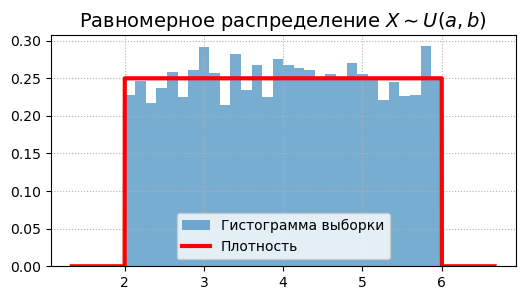

Математическое ожидание: 4.012, теоретически: 4.000
Дисперсия: 1.307, теоретически: 1.333


interactive(children=(FloatSlider(value=0.0, description='x_min', max=5.0, min=-2.0), FloatSlider(value=8.0, d…

In [3]:
print("=== 1. Равномерное распределение ===")
plot_uniform(2, 6, 5000)

ip_rav = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.uniform.pdf),
    distr_name=widgets.fixed(r'$U(a, a + (b-a))$'),
    grid_size=widgets.IntSlider(min=50, max=500, step=50, value=200, description='grid_size'),
    xmin=widgets.FloatSlider(min=-2, max=5, step=0.1, value=0, description='x_min'),
    xmax=widgets.FloatSlider(min=1, max=10, step=0.1, value=8, description='x_max'),
    loc=widgets.FloatSlider(min=0, max=5, step=0.1, value=2, description='a'),
    scale=widgets.FloatSlider(min=0.1, max=6, step=0.1, value=4, description='b-a')
)
display(ip_rav)


=== 2. Экспоненциальное распределение ===


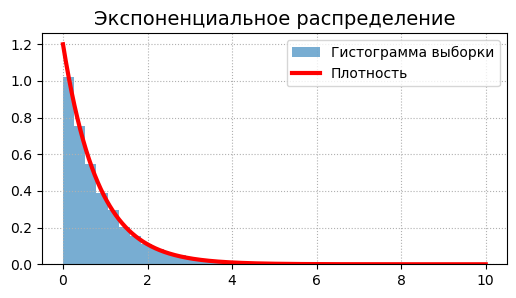

Математическое ожидание: 0.838, теоретически: 0.833
Дисперсия: 0.720, теоретически: 0.694


interactive(children=(FloatSlider(value=0.0, description='x_min', max=1.0), FloatSlider(value=8.0, description…

In [4]:
print("\n=== 2. Экспоненциальное распределение ===")
plot_exp(lmbd=1.2, n_points=10000)

ip_exp = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.expon.pdf),
    distr_name=widgets.fixed(r'$\mathrm{Exp}(\lambda)$'),
    grid_size=widgets.IntSlider(min=50, max=500, step=50, value=200, description='grid_size'),
    xmin=widgets.FloatSlider(min=0, max=1, step=0.1, value=0, description='x_min'),
    xmax=widgets.FloatSlider(min=2, max=15, step=0.1, value=8, description='x_max'),
    scale=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1/1.2, description='1/λ')
)
display(ip_exp)



=== 3. Нормальное распределение ===


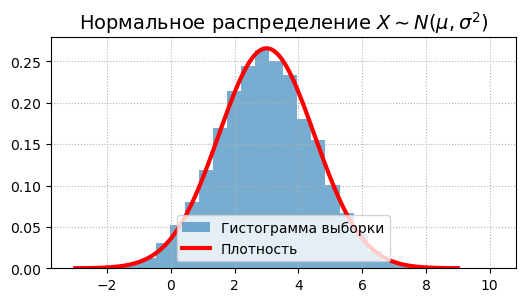

Математическое ожидание: 2.976, теоретически: 3.000
Дисперсия: 2.292, теоретически: 2.250


interactive(children=(FloatSlider(value=-2.0, description='x_min', max=5.0, min=-5.0), FloatSlider(value=8.0, …

In [5]:
print("\n=== 3. Нормальное распределение ===")
plot_norm(mu=3, sigma=1.5, n_points=10000)

ip_norm = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.norm.pdf),
    distr_name=widgets.fixed(r'$N(\mu, \sigma^2)$'),
    grid_size=widgets.IntSlider(min=50, max=500, step=50, value=200, description='grid_size'),
    xmin=widgets.FloatSlider(min=-5, max=5, step=0.1, value=-2, description='x_min'),
    xmax=widgets.FloatSlider(min=5, max=15, step=0.1, value=8, description='x_max'),
    loc=widgets.FloatSlider(min=-3, max=10, step=0.1, value=3, description='μ'),
    scale=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1.5, description='σ')
)
display(ip_norm)


=== 4. Распределение Стьюдента ===


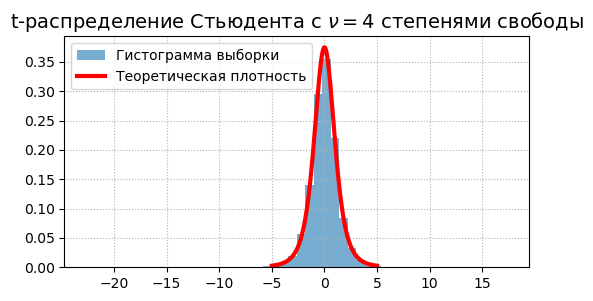

Степени свободы: ν = 4
Математическое ожидание: -0.022, теоретически: 0.000
Дисперсия: 1.997, теоретически: 2.000


interactive(children=(FloatSlider(value=-6.0, description='x_min', max=-1.0, min=-10.0, step=0.5), FloatSlider…

In [6]:
print("\n=== 4. Распределение Стьюдента ===")
plot_t(df=4, n_points=15000)

ip_t = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.t.pdf),
    distr_name=widgets.fixed(r'$t(\nu)$'),
    grid_size=widgets.IntSlider(min=50, max=500, step=50, value=300, description='grid_size'),
    xmin=widgets.FloatSlider(min=-10, max=-1, step=0.5, value=-6, description='x_min'),
    xmax=widgets.FloatSlider(min=1, max=10, step=0.5, value=6, description='x_max'),
    df=widgets.FloatSlider(min=1, max=30, step=0.5, value=4, description='ν')
)
display(ip_t)